[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahdiabolghasemi/Introduction-To-Machine-Learning/blob/DSB102-S2-2026/Workshops/Week5-lab-Soln.ipynb)

# Week 5 — Tree-Based Methods

**Topics:** Decision trees, pruning, random forests, gradient boosting

---
### Setup — run this cell first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier, plot_tree)
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.metrics import mean_squared_error, accuracy_score
import warnings; warnings.filterwarnings('ignore')

diab = load_diabetes()
Xr  = pd.DataFrame(diab.data, columns=diab.feature_names)
yr  = pd.Series(diab.target, name='progression')
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=0)

wine = load_wine()
Xc  = pd.DataFrame(wine.data, columns=wine.feature_names)
yc  = pd.Series(wine.target, name='variety')
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2,
                                                random_state=0, stratify=yc)
print("Diabetes (regression):", Xr.shape)
print("Wine (classification):", Xc.shape, "  Classes:", list(wine.target_names))

Diabetes (regression): (442, 10)
Wine (classification): (178, 13)   Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


---
## Part 1 — Regression Tree

### 1.1 Tutorial: fit and visualise

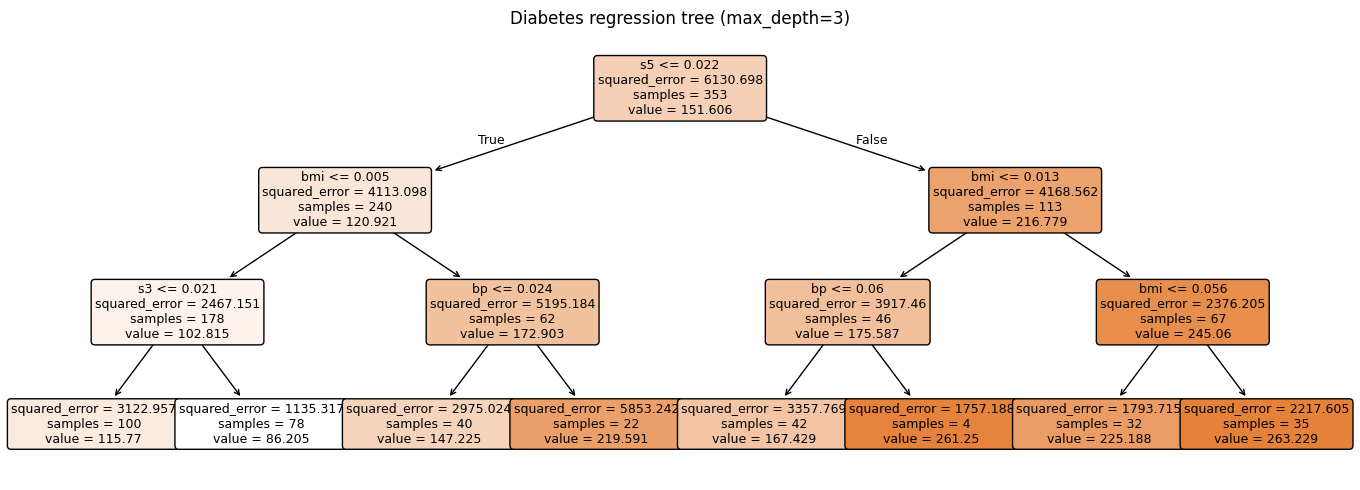

Test RMSE (depth=3): 68.34


In [2]:
# Tutorial: regression tree on diabetes (max_depth=3)
tree_r = DecisionTreeRegressor(max_depth=3, random_state=0).fit(Xr_tr, yr_tr)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(tree_r, feature_names=Xr.columns, filled=True,
          rounded=True, fontsize=9, ax=ax)
plt.title('Diabetes regression tree (max_depth=3)'); plt.tight_layout(); plt.show()

rmse = np.sqrt(mean_squared_error(yr_te, tree_r.predict(Xr_te)))
print(f"Test RMSE (depth=3): {rmse:.2f}")

### 🔧 Exercise 1 — Tune tree depth

**Tasks:**
1. Fit regression trees with `max_depth = 1, 2, 3, 5, 10, None`.
2. Record **train RMSE** and **test RMSE** for each depth, and plot both curves —
   this is for *diagnosis only* (spotting overfitting), not for choosing the
   final depth. Using the test curve to pick a hyperparameter would be the
   same test-set leakage Week 3 warns about.
3. Separately, use 5-fold cross-validation **on the training set only** to
   select the best depth. Refit on the full training set with that depth and
   report the **test RMSE once**.
4. What happens at `max_depth=None`? What is this problem called?

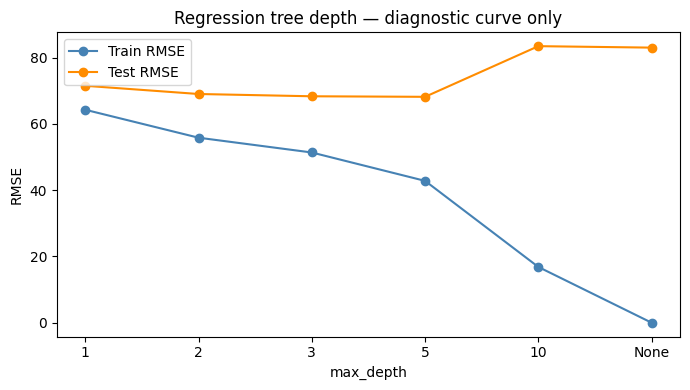

Unlimited depth → zero train RMSE but high test RMSE: overfitting


Best depth (5-fold CV on training set): 3
Test RMSE, evaluated once with that depth: 68.34


In [3]:
# ── SOLUTION Exercise 1 ──────────────────────────────────────────────────────
depths = [1, 2, 3, 5, 10, None]
train_rmse, test_rmse = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=0).fit(Xr_tr, yr_tr)
    train_rmse.append(np.sqrt(mean_squared_error(yr_tr, t.predict(Xr_tr))))
    test_rmse.append(np.sqrt(mean_squared_error(yr_te, t.predict(Xr_te))))

fig, ax = plt.subplots(figsize=(7, 4))
labels = [str(d) for d in depths]
ax.plot(labels, train_rmse, 'o-', label='Train RMSE', color='steelblue')
ax.plot(labels, test_rmse,  'o-', label='Test RMSE',  color='darkorange')
ax.set(xlabel='max_depth', ylabel='RMSE', title='Regression tree depth — diagnostic curve only')
ax.legend(); plt.tight_layout(); plt.show()
print("Unlimited depth → zero train RMSE but high test RMSE: overfitting")

# Select max_depth properly: 5-fold CV on the TRAINING set only. The test
# curve above is for spotting overfitting -- it must not be used to choose
# the hyperparameter that gets deployed.
cv_rmse = []
for d in depths:
    scores = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=0),
                              Xr_tr, yr_tr, cv=5, scoring='neg_mean_squared_error')
    cv_rmse.append(np.sqrt(-scores.mean()))

best_depth = depths[int(np.argmin(cv_rmse))]
tree_r_best = DecisionTreeRegressor(max_depth=best_depth, random_state=0).fit(Xr_tr, yr_tr)
rmse_tree_best = np.sqrt(mean_squared_error(yr_te, tree_r_best.predict(Xr_te)))
print(f"Best depth (5-fold CV on training set): {best_depth}")
print(f"Test RMSE, evaluated once with that depth: {rmse_tree_best:.2f}")

---
## Part 2 — Classification Tree and Pruning

### 2.1 Tutorial: wine classification tree

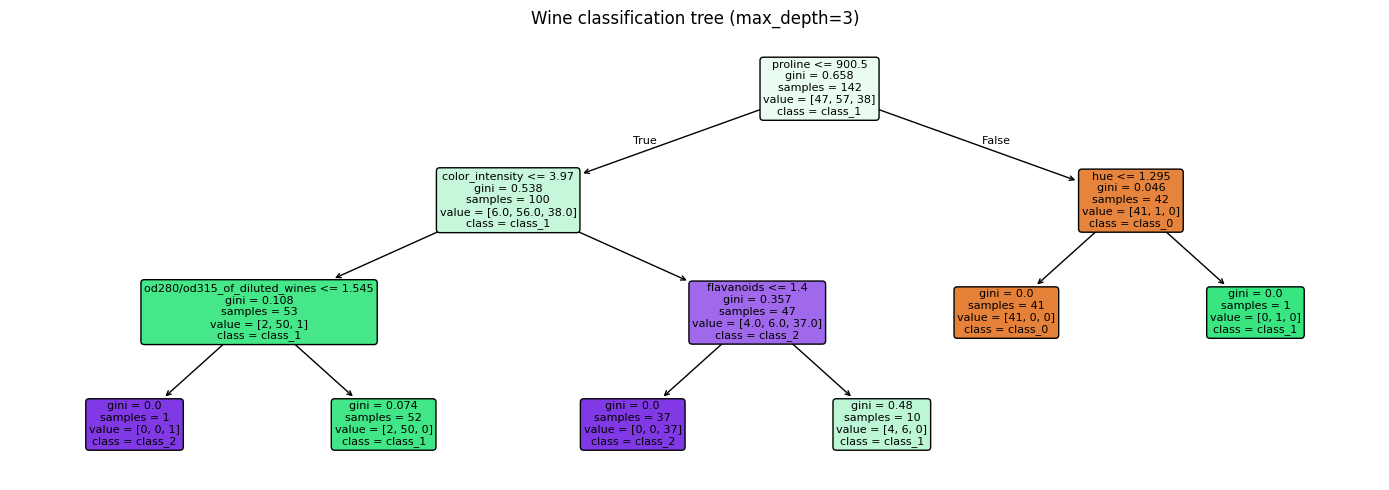

Test accuracy (depth=3): 0.806
First split on: 'proline'


In [4]:
# Tutorial: classification tree (max_depth=3)
tree_c = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xc_tr, yc_tr)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(tree_c, feature_names=Xc.columns, class_names=wine.target_names,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Wine classification tree (max_depth=3)'); plt.tight_layout(); plt.show()

print(f"Test accuracy (depth=3): {accuracy_score(yc_te, tree_c.predict(Xc_te)):.3f}")
print(f"First split on: '{Xc.columns[tree_c.tree_.feature[0]]}'")

### 🔧 Exercise 2 — Cost-complexity pruning

**Tasks:**
1. Fit trees with `ccp_alpha = 0, 0.001, 0.005, 0.01, 0.02, 0.05`.
2. For each alpha, compute 5-fold CV accuracy **on the training set** (not the
   test set) and plot CV accuracy vs `ccp_alpha`.
3. Which `ccp_alpha` gives the best CV accuracy? Refit on the full training
   set with that alpha and report the test accuracy once.
4. How many leaves does the best pruned tree have? (`tree.get_n_leaves()`)

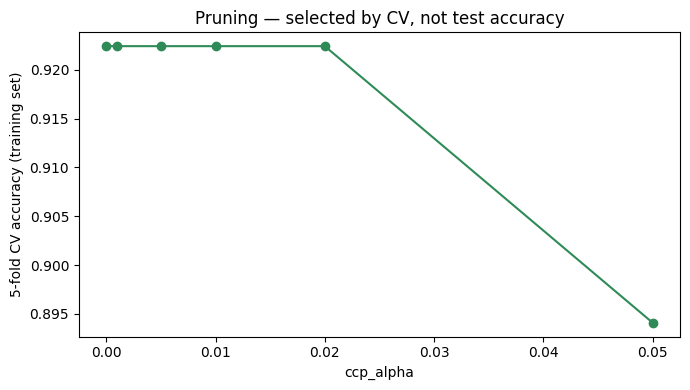

Best ccp_alpha (5-fold CV on training set): 0
Test accuracy, evaluated once with that alpha: 0.944
Leaves in pruned tree: 9


In [5]:
# ── SOLUTION Exercise 2 ──────────────────────────────────────────────────────
alphas = [0, 0.001, 0.005, 0.01, 0.02, 0.05]
cv_accs = []
for a in alphas:
    scores = cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=0),
                              Xc_tr, yc_tr, cv=5, scoring='accuracy')
    cv_accs.append(scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(alphas, cv_accs, 'o-', color='seagreen')
plt.xlabel('ccp_alpha'); plt.ylabel('5-fold CV accuracy (training set)')
plt.title('Pruning — selected by CV, not test accuracy')
plt.tight_layout(); plt.show()

best_a = alphas[int(np.argmax(cv_accs))]
t_best = DecisionTreeClassifier(ccp_alpha=best_a, random_state=0).fit(Xc_tr, yc_tr)
test_acc_best = accuracy_score(yc_te, t_best.predict(Xc_te))
print(f"Best ccp_alpha (5-fold CV on training set): {best_a}")
print(f"Test accuracy, evaluated once with that alpha: {test_acc_best:.3f}")
print(f"Leaves in pruned tree: {t_best.get_n_leaves()}")

---
## Part 3 — Random Forest

### 3.1 Tutorial: aggregating many trees

Random Forest test RMSE: 60.51


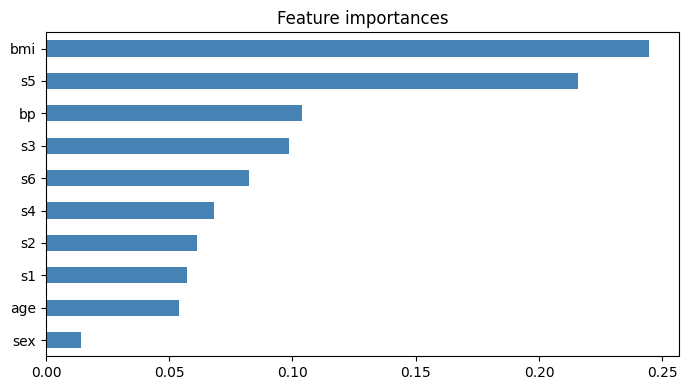

In [6]:
# Tutorial: random forest on diabetes
rf = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=0)
rf.fit(Xr_tr, yr_tr)
rmse_rf = np.sqrt(mean_squared_error(yr_te, rf.predict(Xr_te)))
print(f"Random Forest test RMSE: {rmse_rf:.2f}")

imp = pd.Series(rf.feature_importances_, index=Xr.columns).sort_values(ascending=True)
imp.plot(kind='barh', figsize=(7, 4), color='steelblue', title='Feature importances')
plt.tight_layout(); plt.show()

### 🔧 Exercise 3 — Tune random forest on wine

**Tasks:**
1. Fit `RandomForestClassifier` on the wine dataset. Evaluate test accuracy.
2. Try `max_features = 1, 3, 6, 13, 'sqrt'`, selected by 5-fold CV **on the
   training set**. Which works best? Refit on the full training set with the
   best value and report the test accuracy once.
3. Plot feature importances. What is the most important feature for wine variety?
4. Compare test accuracy: single tree (best depth) vs random forest.

Random Forest (default max_features) test accuracy: 1.000


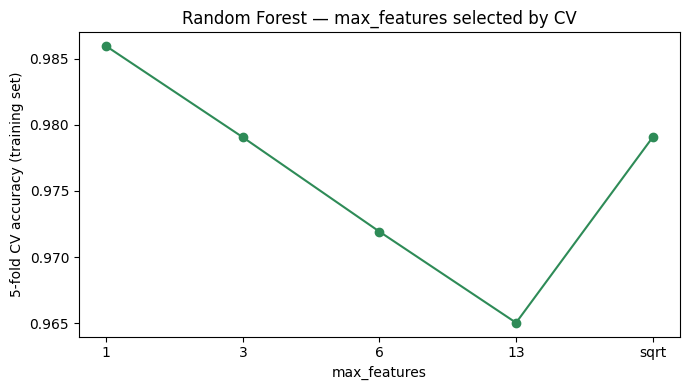

Best max_features (5-fold CV on training set): 1
Test accuracy, evaluated once with that value: 1.000
Single tree (depth=3): 0.806


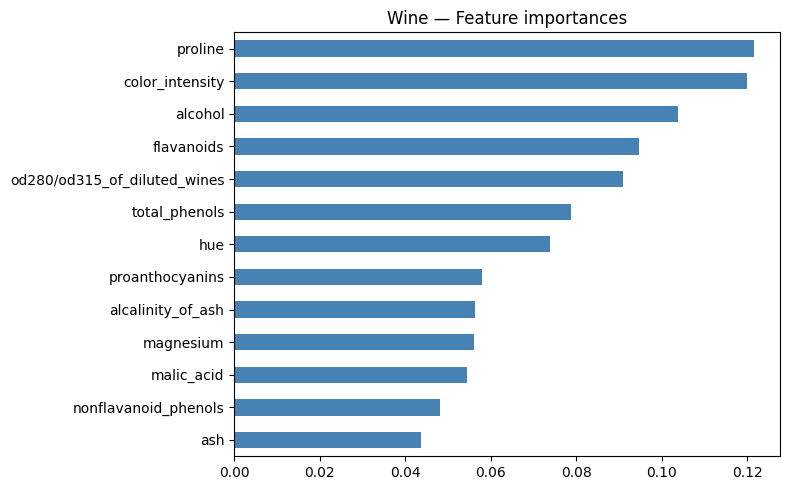

In [7]:
# ── SOLUTION Exercise 3 ──────────────────────────────────────────────────────
rf0 = RandomForestClassifier(n_estimators=200, max_features='sqrt', random_state=0)
rf0.fit(Xc_tr, yc_tr)
print(f"Random Forest (default max_features) test accuracy: "
      f"{accuracy_score(yc_te, rf0.predict(Xc_te)):.3f}")

max_feats = [1, 3, 6, 13, 'sqrt']
cv_rf_accs = []
for mf in max_feats:
    rf_c = RandomForestClassifier(n_estimators=200, max_features=mf, random_state=0)
    scores = cross_val_score(rf_c, Xc_tr, yc_tr, cv=5, scoring='accuracy')
    cv_rf_accs.append(scores.mean())

labels = [str(m) for m in max_feats]
plt.figure(figsize=(7, 4))
plt.plot(labels, cv_rf_accs, 'o-', color='seagreen')
plt.xlabel('max_features'); plt.ylabel('5-fold CV accuracy (training set)')
plt.title('Random Forest — max_features selected by CV'); plt.tight_layout(); plt.show()

best_mf = max_feats[int(np.argmax(cv_rf_accs))]
rf_best = RandomForestClassifier(n_estimators=200, max_features=best_mf, random_state=0)
rf_best.fit(Xc_tr, yc_tr)
test_acc_rf_best = accuracy_score(yc_te, rf_best.predict(Xc_te))
print(f"Best max_features (5-fold CV on training set): {best_mf}")
print(f"Test accuracy, evaluated once with that value: {test_acc_rf_best:.3f}")
print(f"Single tree (depth=3): {accuracy_score(yc_te, tree_c.predict(Xc_te)):.3f}")

imp_c = pd.Series(rf_best.feature_importances_, index=Xc.columns).sort_values(ascending=True)
imp_c.plot(kind='barh', figsize=(8, 5), color='steelblue', title='Wine — Feature importances')
plt.tight_layout(); plt.show()

---
## Part 4 — Gradient Boosting

### 4.1 Tutorial: building trees sequentially

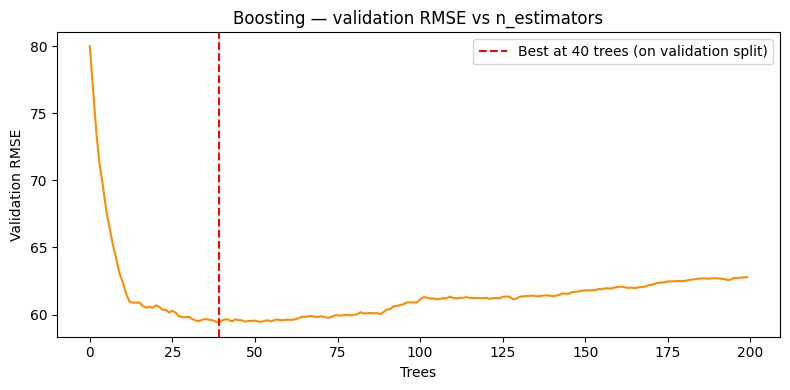

Gradient Boosting test RMSE (40 trees): 61.94


In [8]:
# Tutorial: gradient boosting on diabetes -- choosing the number of trees
# To find a good number of trees, track staged performance on a validation
# split carved out of the TRAINING set, not the test set (same rule as
# everywhere else this week: touch the test set only once, for the final
# number reported below).
Xr_tr2, Xr_val, yr_tr2, yr_val = train_test_split(Xr_tr, yr_tr, test_size=0.25, random_state=1)

gb_search = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                       max_depth=3, random_state=0).fit(Xr_tr2, yr_tr2)
rmse_staged = [np.sqrt(mean_squared_error(yr_val, p)) for p in gb_search.staged_predict(Xr_val)]
best_n_trees = int(np.argmin(rmse_staged)) + 1

plt.figure(figsize=(8, 4))
plt.plot(rmse_staged, color='darkorange')
plt.axvline(best_n_trees - 1, color='red', ls='--',
            label=f'Best at {best_n_trees} trees (on validation split)')
plt.xlabel('Trees'); plt.ylabel('Validation RMSE'); plt.legend()
plt.title('Boosting — validation RMSE vs n_estimators'); plt.tight_layout(); plt.show()

# Refit on the FULL training set with the selected number of trees, then
# evaluate once on the test set.
gb = GradientBoostingRegressor(n_estimators=best_n_trees, learning_rate=0.1,
                                max_depth=3, random_state=0).fit(Xr_tr, yr_tr)
print(f"Gradient Boosting test RMSE ({best_n_trees} trees): "
      f"{np.sqrt(mean_squared_error(yr_te, gb.predict(Xr_te))):.2f}")

### 🔧 Exercise 4 — Compare all methods

**Tasks:**
1. Fit `GradientBoostingClassifier(n_estimators=200, learning_rate=0.05)` on wine.
2. Fill in this comparison table:

| Method | Wine Accuracy | Diabetes RMSE |
|---|---|---|
| Single Tree (best depth/alpha) | | |
| Random Forest | | |
| Gradient Boosting | | |

3. What is the key difference between bagging (RF) and boosting in how they use trees?

In [9]:
# ── SOLUTION Exercise 4 ──────────────────────────────────────────────────────
gbc = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=0)
gbc.fit(Xc_tr, yc_tr)
acc_gb = accuracy_score(yc_te, gbc.predict(Xc_te))

rmse_gb = np.sqrt(mean_squared_error(yr_te, gb.predict(Xr_te)))
# "Single Tree" and "Random Forest" below use the CV-selected models from
# Exercises 1-3 (test set touched once each), not the best-of-test-sweep
# values a naive comparison would use.

print("\nModel comparison:")
print(f"{'Method':30s} {'Wine Acc':>12} {'Diabetes RMSE':>15}")
print("-" * 58)
print(f"{'Single Tree':30s} {test_acc_best:>12.3f} {rmse_tree_best:>15.2f}")
print(f"{'Random Forest':30s} {test_acc_rf_best:>12.3f} {rmse_rf:>15.2f}")
print(f"{'Gradient Boosting':30s} {acc_gb:>12.3f} {rmse_gb:>15.2f}")
print("\nBagging: independent trees on bootstrap samples, averaged.")
print("Boosting: sequential trees, each correcting predecessor's errors.")


Model comparison:
Method                             Wine Acc   Diabetes RMSE
----------------------------------------------------------
Single Tree                           0.944           68.34
Random Forest                         1.000           60.51
Gradient Boosting                     0.972           61.94

Bagging: independent trees on bootstrap samples, averaged.
Boosting: sequential trees, each correcting predecessor's errors.


---
## Summary

| Method | Idea | Strength | Weakness |
|---|---|---|---|
| **Decision Tree** | Recursive binary splits | Interpretable, visual | High variance |
| **Random Forest** | Average many trees | Low variance, robust | Less interpretable |
| **Gradient Boosting** | Trees correct previous residuals | Highest accuracy | Needs careful tuning |